Saving bank-full.csv to bank-full (9).csv
Shape: (45211, 17)
y
0    39922
1     5289
Name: count, dtype: int64

=== LOGISTIC REGRESSION ===
[[7792  160]
 [ 854  237]]
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7952
           1       0.60      0.22      0.32      1091

    accuracy                           0.89      9043
   macro avg       0.75      0.60      0.63      9043
weighted avg       0.86      0.89      0.86      9043

F1: 0.3185483870967742

=== RANDOM FOREST ===
[[7694  258]
 [ 642  449]]
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7952
           1       0.64      0.41      0.50      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.69      0.72      9043
weighted avg       0.89      0.90      0.89      9043

F1: 0.4994438264738598


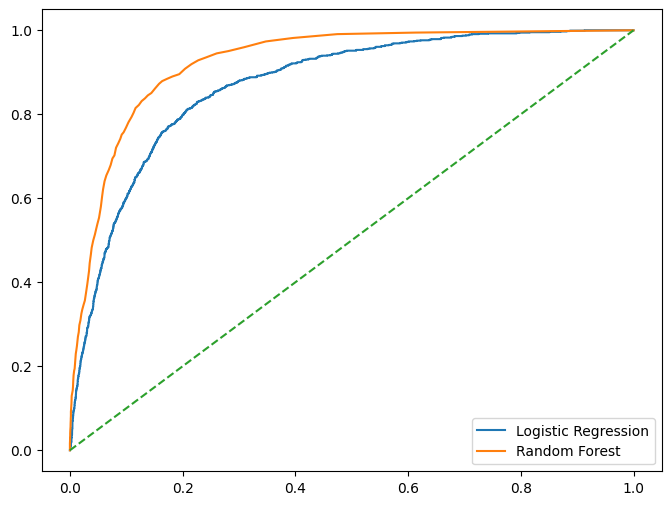

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve

# =========================
# LOAD DATA
# =========================
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename, sep=';', engine='python', quoting=3)

print("Shape:", df.shape)

# =========================
# CLEAN COLUMNS
# =========================
df.columns = df.columns.str.replace('"', '').str.strip()
df = df.map(lambda x: x.replace('"', '') if isinstance(x, str) else x)

# =========================
# TARGET
# =========================
df['y'] = df['y'].map({'yes': 1, 'no': 0})

print(df['y'].value_counts())

# =========================
# ENCODING
# =========================
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# =========================
# SPLIT
# =========================
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# SCALE (ONLY FOR LOGISTIC REGRESSION)
# =========================
scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train)
X_test_lr = scaler.transform(X_test)

# =========================
# LOGISTIC REGRESSION
# =========================
lr = LogisticRegression(max_iter=3000)
lr.fit(X_train_lr, y_train)
y_pred_lr = lr.predict(X_test_lr)

# =========================
# RANDOM FOREST (NO SCALING)
# =========================
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# =========================
# EVALUATION
# =========================
print("\n=== LOGISTIC REGRESSION ===")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("F1:", f1_score(y_test, y_pred_lr))

print("\n=== RANDOM FOREST ===")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))

# =========================
# ROC CURVE
# =========================
y_prob_lr = lr.predict_proba(X_test_lr)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.show()
!pip install shap
import shap
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values[1], X_test)
for i in range(5):
    shap.force_plot(
        explainer.expected_value[1],
        shap_values[1][i],
        X_test.iloc[i],
        matplotlib=True
    )
